In [ ]:
import pandas as pd
import numpy as np
import sympy as sp
import seaborn as sns
import matplotlib.pyplot as plt

# Методичка

## PCA на сгенерированных данных

In [ ]:
n_samples = 100
x = np.random.normal(0, 1, n_samples)  # Первый признак
y = 2 * x + np.random.normal(0, 0.5, n_samples)  # Второй признак (коррелирован с первым)

X = np.column_stack((x, y))

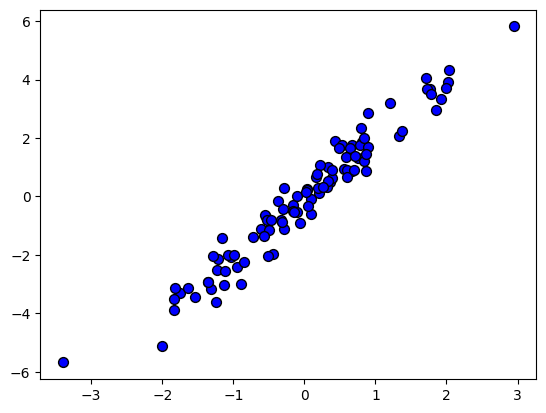

In [ ]:
plt.scatter(x, y, c='blue', edgecolor='k', s=50)

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

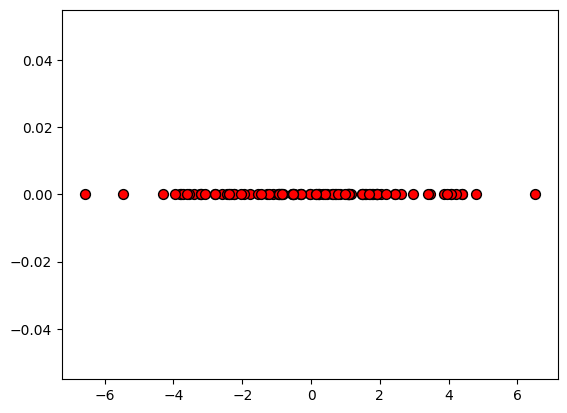

In [ ]:
plt.scatter(X_pca, np.zeros_like(X_pca), c='red', edgecolor='k', s=50)

In [ ]:
print(f"Главная компонента (направление): {pca.components_}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_}")

Главная компонента (направление): [[0.4314071  0.90215737]]
Объясненная дисперсия: [0.99228298]


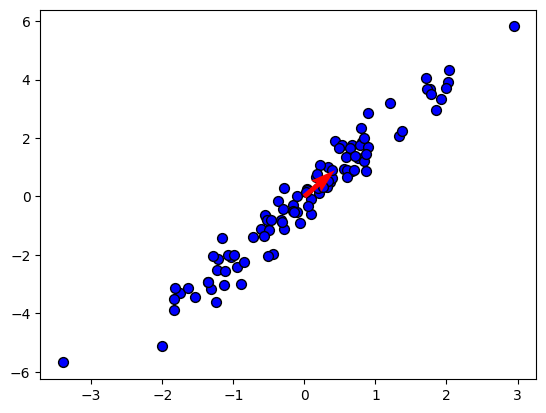

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k', s=50)
pc1_direction = pca.components_[0]
plt.quiver(0, 0, pc1_direction[0], pc1_direction[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

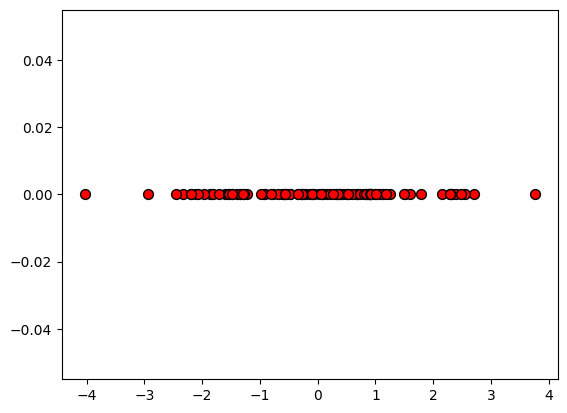

In [ ]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca, np.zeros_like(X_pca), c='red', edgecolor='k', s=50)

## PCA на многомерных данных

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
X.shape

(569, 30)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)  # Уменьшаем до 2 компонент
X_pca = pca.fit_transform(X_scaled)

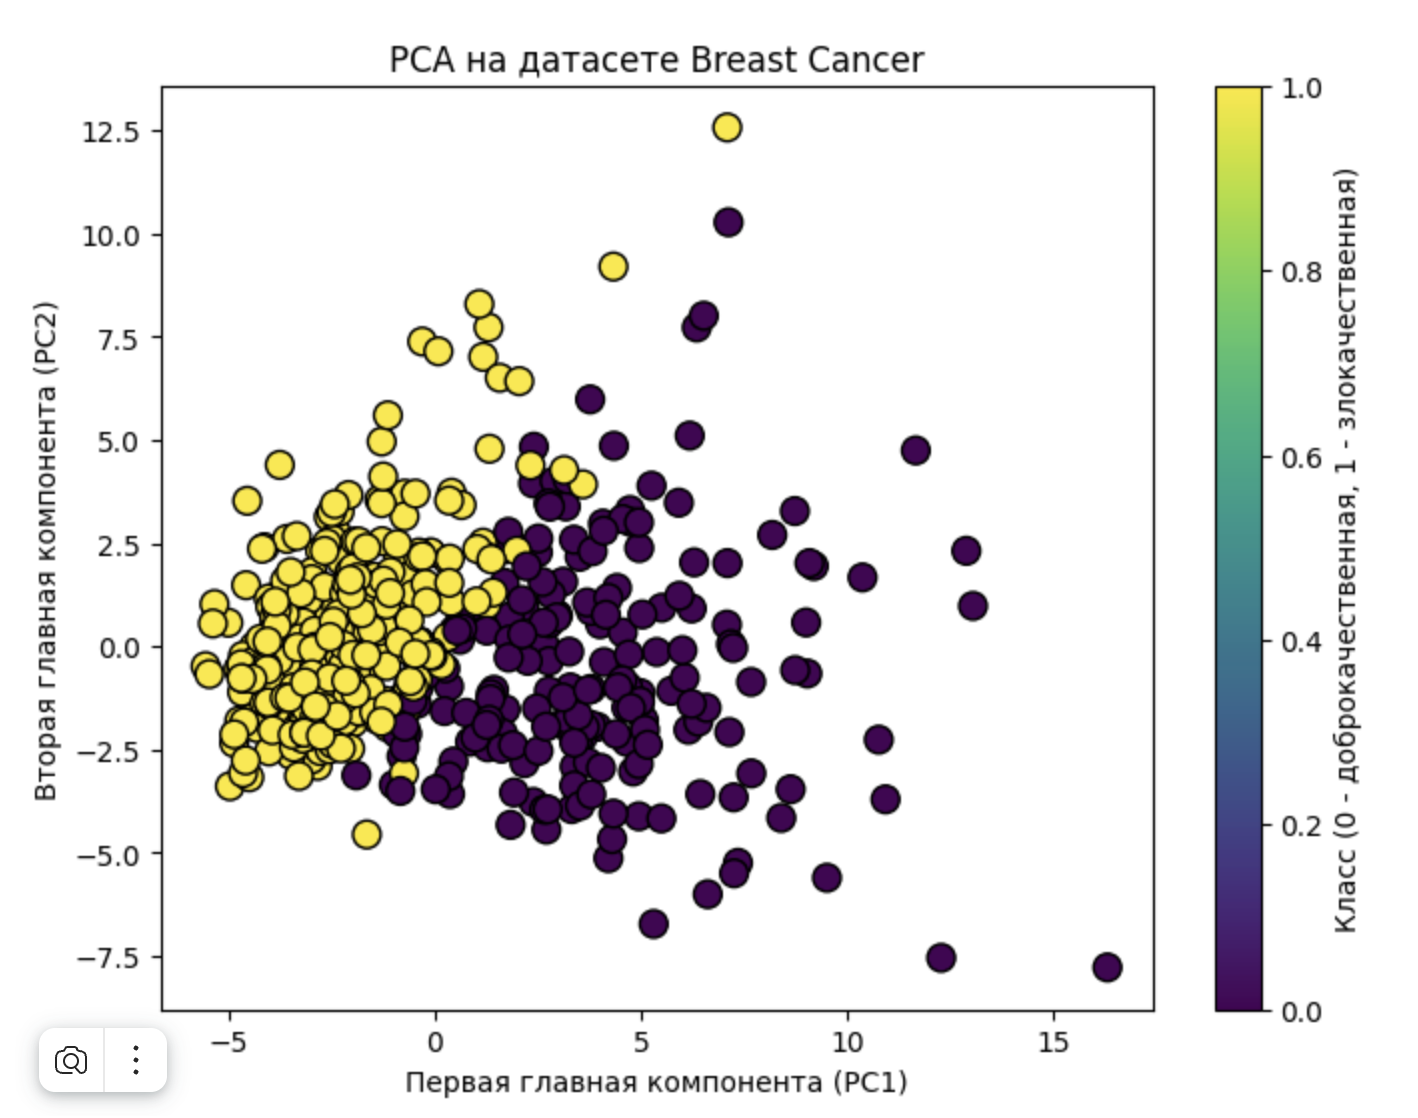

In [ ]:
print(f"Главная компонента (направление): {pca.components_}")

Главная компонента (направление): [[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


In [ ]:
explained_variance = pca.explained_variance_ratio_
print(f"Объясненная дисперсия каждой компоненты: {explained_variance}")
print(f"Суммарная объясненная дисперсия: {sum(explained_variance):.2f}")

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182]
Суммарная объясненная дисперсия: 0.63


## Метод локтя для PCA

In [ ]:
n_components_range = range(1, 31)
explained_variance = []

In [ ]:
for n in n_components_range:
    pca = PCA(n_components=n)
    pca.fit(X_scaled)
    explained_variance.append(sum(pca.explained_variance_ratio_))

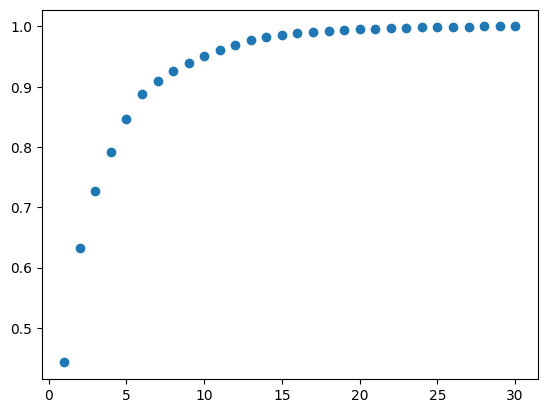

In [ ]:
plt.scatter(n_components_range, explained_variance)

In [ ]:
pca = PCA(n_components=7)  # Уменьшаем до 7 компонент
X_pca = pca.fit_transform(X_scaled)

# Объясненная дисперсия
explained_variance = pca.explained_variance_ratio_
print(f"Объясненная дисперсия каждой компоненты: {explained_variance}")
print(f"Суммарная объясненная дисперсия: {sum(explained_variance):.2f}")

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734]
Суммарная объясненная дисперсия: 0.91


## Метод LDA

In [ ]:
n_samples = 100

x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(6, 1, n_samples)
y2 = np.random.normal(6, 1, n_samples)

X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

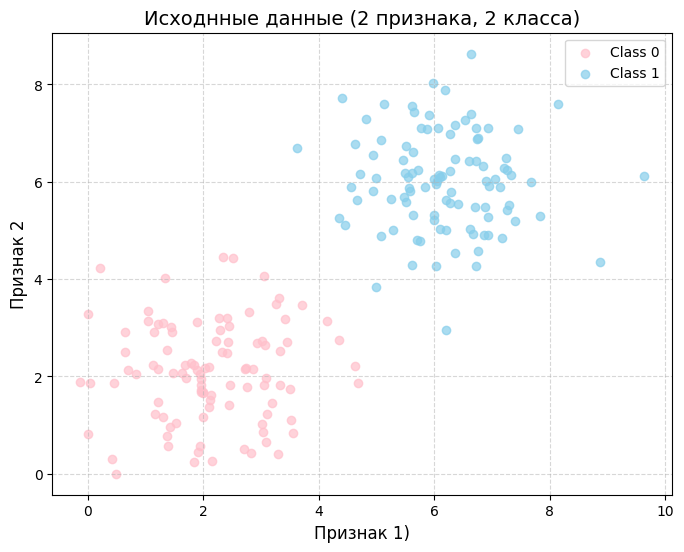

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(X[y == 0, 0], X[y == 0, 1], c='pink', label='Class 0', alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='skyblue', label='Class 1', alpha=0.7)
plt.title('Исходнные данные (2 признака, 2 класса)', fontsize=14)
plt.xlabel('Признак 1)', fontsize=12)
plt.ylabel('Признак 2', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

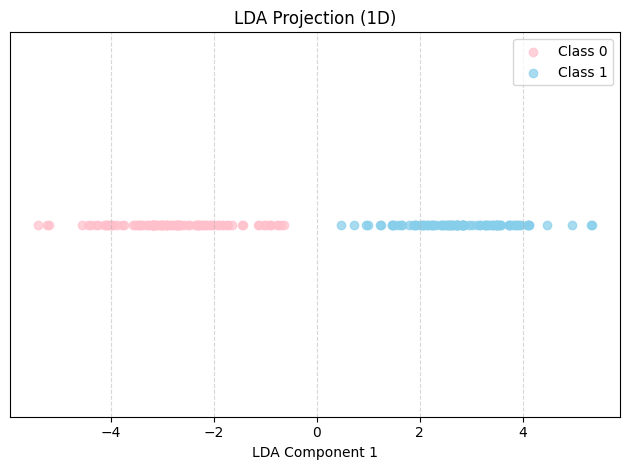

In [ ]:
plt.scatter(X_lda[y==0], np.zeros_like(X_lda[y==0]),
            c='pink', alpha=0.7, label='Class 0')
plt.scatter(X_lda[y==1], np.zeros_like(X_lda[y==1]),
            c='skyblue', alpha=0.7, label='Class 1')
plt.title('LDA Projection (1D)')
plt.xlabel('LDA Component 1')
plt.yticks([])  # Hide y-axis as we're showing 1D projection
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Коэффициенты LDA: {lda.coef_}")

Коэффициенты LDA: [[9.01808333 8.55473013]]


In [ ]:
lda_direction = lda.coef_[0]

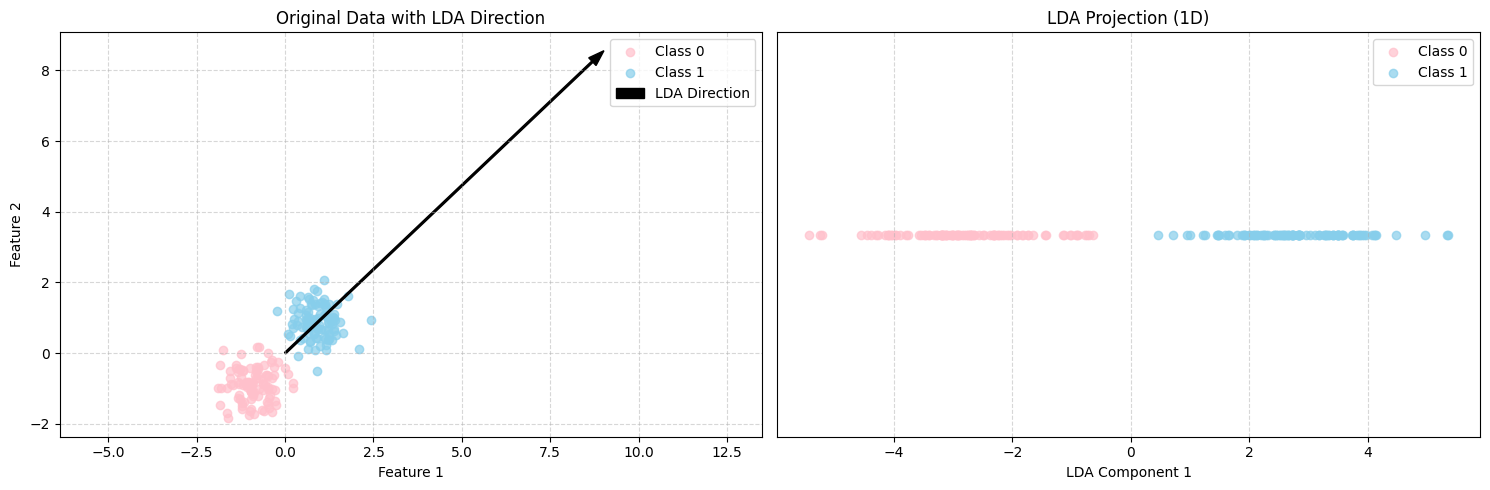

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[y==0, 0], X_scaled[y==0, 1], c='pink', alpha=0.7, label='Class 0')
plt.scatter(X_scaled[y==1, 0], X_scaled[y==1, 1], c='skyblue', alpha=0.7, label='Class 1')


mean = np.mean(X_scaled, axis=0)
plt.arrow(mean[0], mean[1], lda_direction[0], lda_direction[1],
          color='black', width=0.05, head_width=0.3, length_includes_head=True,
          label='LDA Direction')

plt.title('Original Data with LDA Direction')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')

plt.subplot(1, 2, 2)
plt.scatter(X_lda[y==0], np.zeros_like(X_lda[y==0]),
            c='pink', alpha=0.7, label='Class 0')
plt.scatter(X_lda[y==1], np.zeros_like(X_lda[y==1]),
            c='skyblue', alpha=0.7, label='Class 1')
plt.title('LDA Projection (1D)')
plt.xlabel('LDA Component 1')
plt.yticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Метод LDA для анизатропных классов

In [ ]:
from sklearn.datasets import make_blobs, make_circles

In [ ]:
X, y = make_blobs(n_samples=200, random_state=170, centers=2)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X = np.dot(X, transformation)

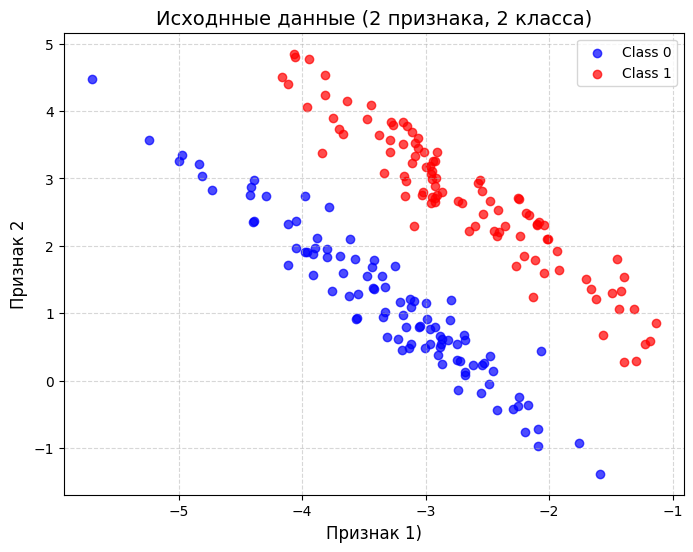

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Class 0', alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Class 1', alpha=0.7)
plt.title('Исходнные данные (2 признака, 2 класса)', fontsize=14)
plt.xlabel('Признак 1)', fontsize=12)
plt.ylabel('Признак 2', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

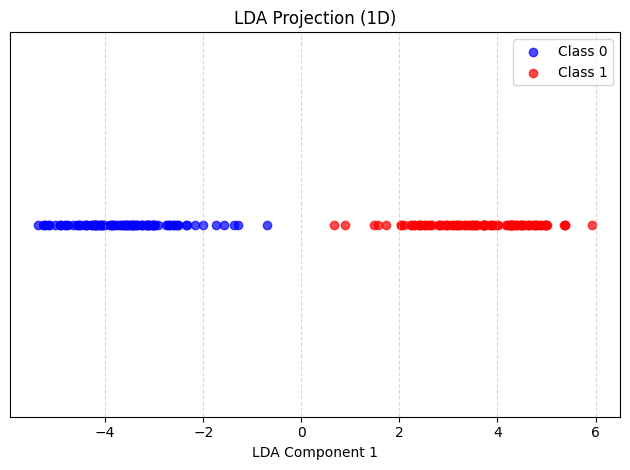

In [ ]:
plt.scatter(X_lda[y==0], np.zeros_like(X_lda[y==0]),
            c='blue', alpha=0.7, label='Class 0')
plt.scatter(X_lda[y==1], np.zeros_like(X_lda[y==1]),
            c='red', alpha=0.7, label='Class 1')
plt.title('LDA Projection (1D)')
plt.xlabel('LDA Component 1')
plt.yticks([])  # Hide y-axis as we're showing 1D projection
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

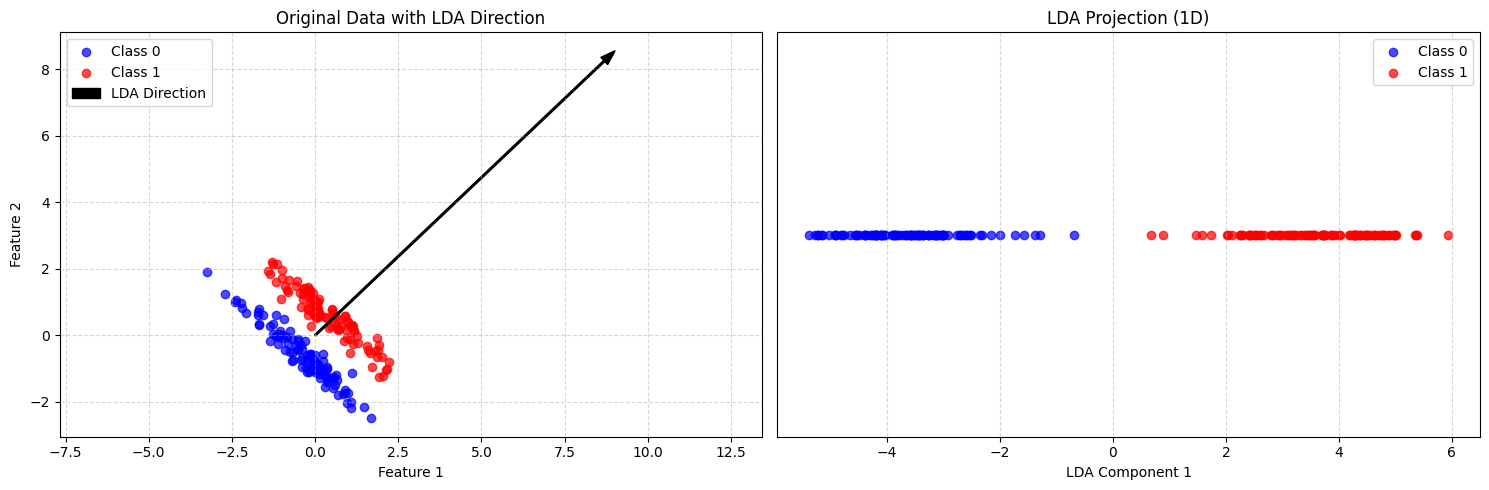

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[y==0, 0], X_scaled[y==0, 1], c='blue', alpha=0.7, label='Class 0')
plt.scatter(X_scaled[y==1, 0], X_scaled[y==1, 1], c='red', alpha=0.7, label='Class 1')


mean = np.mean(X_scaled, axis=0)
plt.arrow(mean[0], mean[1], lda_direction[0], lda_direction[1],
          color='black', width=0.05, head_width=0.3, length_includes_head=True,
          label='LDA Direction')

plt.title('Original Data with LDA Direction')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')

# LDA projection
plt.subplot(1, 2, 2)
plt.scatter(X_lda[y==0], np.zeros_like(X_lda[y==0]),
            c='blue', alpha=0.7, label='Class 0')
plt.scatter(X_lda[y==1], np.zeros_like(X_lda[y==1]),
            c='red', alpha=0.7, label='Class 1')
plt.title('LDA Projection (1D)')
plt.xlabel('LDA Component 1')
plt.yticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

pca_direction = pca.components_[0]  # First principal component

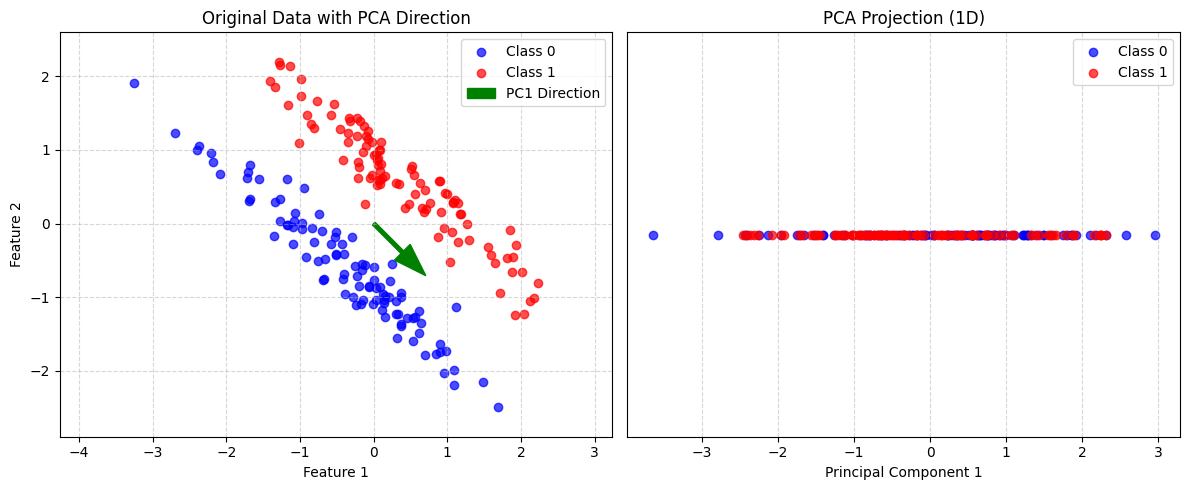

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[y==0, 0], X_scaled[y==0, 1], c='blue', alpha=0.7, label='Class 0')
plt.scatter(X_scaled[y==1, 0], X_scaled[y==1, 1], c='red', alpha=0.7, label='Class 1')

mean = np.mean(X_scaled, axis=0)
plt.arrow(mean[0], mean[1], pca_direction[0], pca_direction[1],
          color='green', width=0.05, head_width=0.3, length_includes_head=True,
          label='PC1 Direction')

plt.title('Original Data with PCA Direction')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')

# PCA projection
plt.subplot(1, 2, 2)
plt.scatter(X_pca[y==0], np.zeros_like(X_pca[y==0]),
            c='blue', alpha=0.7, label='Class 0')
plt.scatter(X_pca[y==1], np.zeros_like(X_pca[y==1]),
            c='red', alpha=0.7, label='Class 1')
plt.title('PCA Projection (1D)')
plt.xlabel('Principal Component 1')
plt.yticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Метод t-SNE

In [ ]:
n_samples = 100

x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(6, 1, n_samples)
y2 = np.random.normal(6, 1, n_samples)

X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

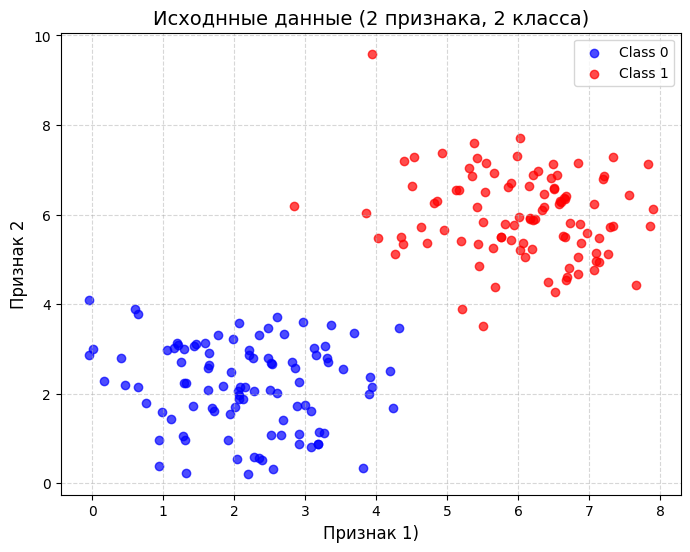

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Class 0', alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Class 1', alpha=0.7)
plt.title('Исходнные данные (2 признака, 2 класса)', fontsize=14)
plt.xlabel('Признак 1)', fontsize=12)
plt.ylabel('Признак 2', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
from sklearn.manifold import TSNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(n_components=1, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

In [ ]:
perplexity_values = [5, 30, 50]

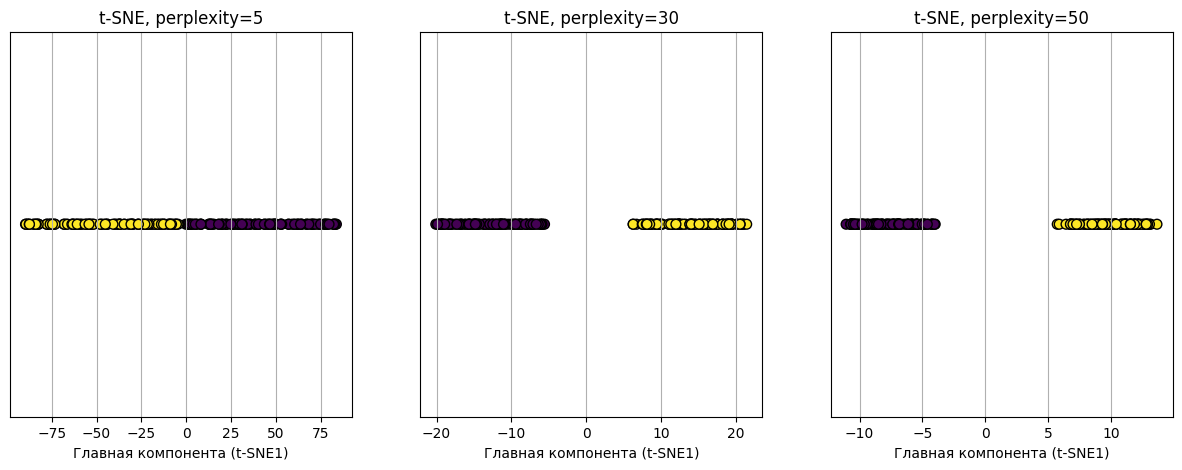

In [ ]:
plt.figure(figsize=(15, 5))
for i, perplexity in enumerate(perplexity_values):
    tsne = TSNE(n_components=1, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.subplot(1, 3, i+1)
    plt.scatter(X_tsne, np.zeros_like(X_tsne), c=y, cmap='viridis', edgecolor='k', s=50)
    plt.title(f't-SNE, perplexity={perplexity}')
    plt.xlabel('Главная компонента (t-SNE1)')
    plt.yticks([])
    plt.grid(True)

## Kernel PCA для нелинейных данных

In [ ]:
X, y = make_circles(n_samples=500, factor=0.3, noise=0.05, random_state=42)

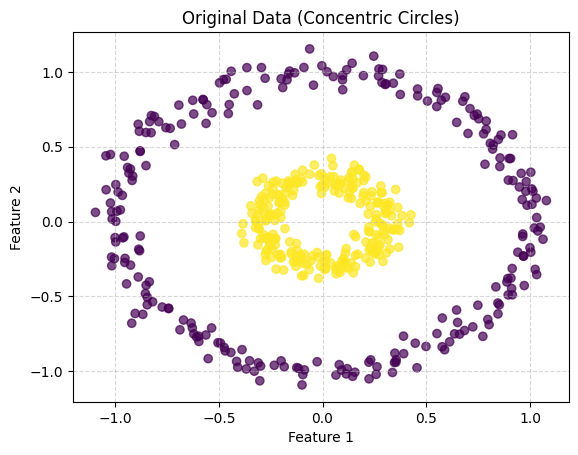

In [ ]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.7)
plt.title("Original Data (Concentric Circles)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle='--', alpha=0.5)

In [ ]:
kernels = ['linear', 'poly', 'rbf']

In [ ]:
from sklearn.decomposition import KernelPCA

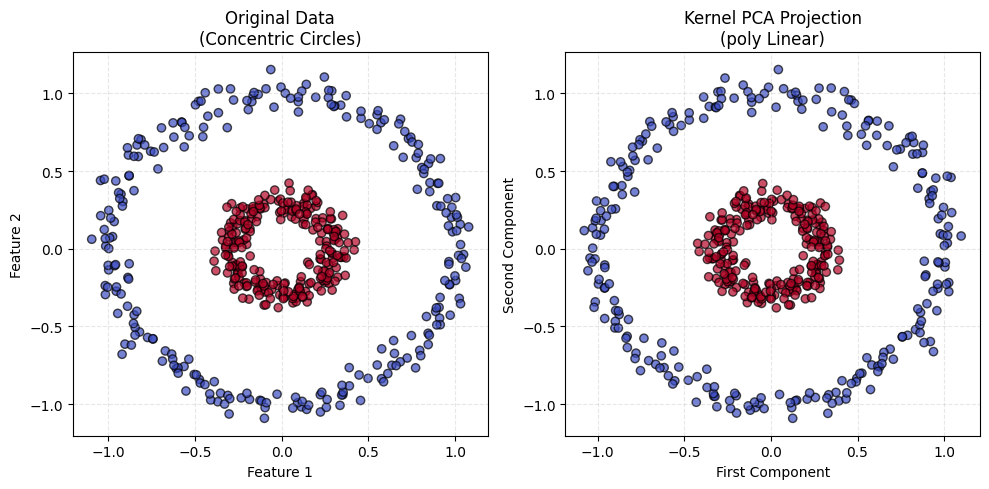

In [ ]:
kpca = KernelPCA(n_components=2, kernel='linear')
X_kpca = kpca.fit_transform(X)

# Create figure
plt.figure(figsize=(10, 5))

# Original Data
plt.subplot(1, 2, 1)
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title("Original Data\n(Concentric Circles)", fontsize=12)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle='--', alpha=0.3)

# Kernel PCA Projection
plt.subplot(1, 2, 2)
plt.scatter(X_kpca[:,0], X_kpca[:,1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title("Kernel PCA Projection\n(poly Linear)", fontsize=12)
plt.xlabel("First Component")
plt.ylabel("Second Component")
plt.grid(True, linestyle='--', alpha=0.3)


plt.tight_layout()
plt.show()

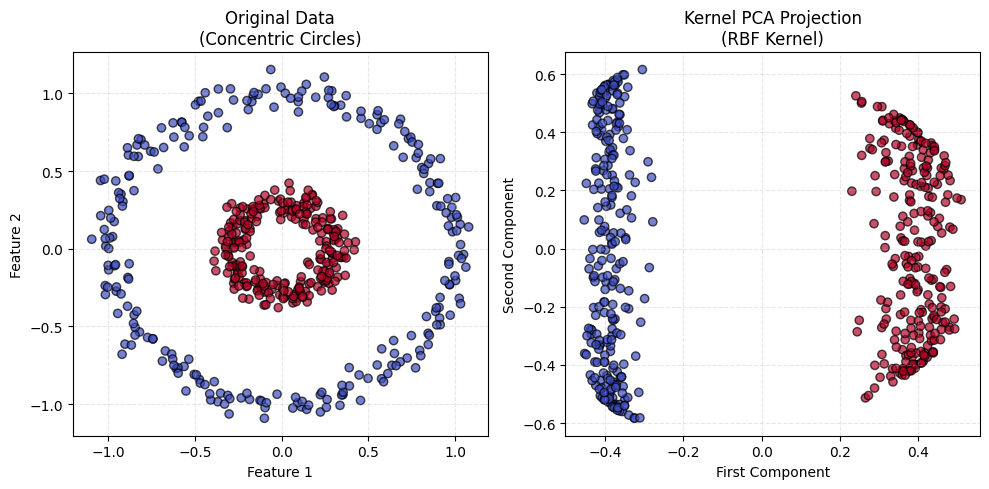

In [ ]:
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=2)
X_kpca = kpca.fit_transform(X)

# Create figure
plt.figure(figsize=(10, 5))

# Original Data
plt.subplot(1, 2, 1)
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title("Original Data\n(Concentric Circles)", fontsize=12)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle='--', alpha=0.3)

# Kernel PCA Projection
plt.subplot(1, 2, 2)
plt.scatter(X_kpca[:,0], X_kpca[:,1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title("Kernel PCA Projection\n(RBF Kernel)", fontsize=12)
plt.xlabel("First Component")
plt.ylabel("Second Component")
plt.grid(True, linestyle='--', alpha=0.3)


plt.tight_layout()
plt.show()

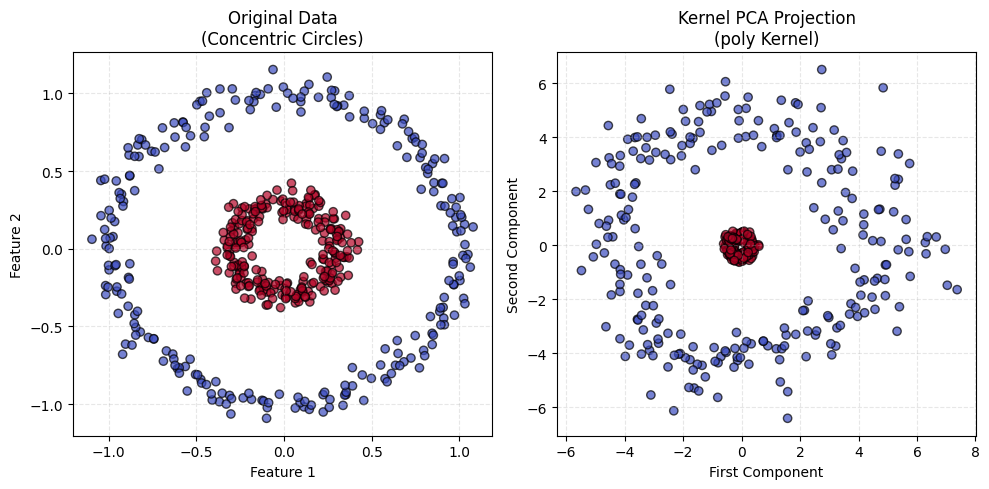

In [ ]:
kpca = KernelPCA(n_components=2, kernel='poly', degree=10)
X_kpca = kpca.fit_transform(X)

# Create figure
plt.figure(figsize=(10, 5))

# Original Data
plt.subplot(1, 2, 1)
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title("Original Data\n(Concentric Circles)", fontsize=12)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle='--', alpha=0.3)

# Kernel PCA Projection
plt.subplot(1, 2, 2)
plt.scatter(X_kpca[:,0], X_kpca[:,1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title("Kernel PCA Projection\n(poly Kernel)", fontsize=12)
plt.xlabel("First Component")
plt.ylabel("Second Component")
plt.grid(True, linestyle='--', alpha=0.3)


plt.tight_layout()
plt.show()